# Week 5 part 2

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

# ===================== CONFIG — the only cell you need to edit =====================

ROOM_SLUG, TAG  = "room_009", "30min"   # which prepared dataset to read

# --- Covariates entering the transition -------------------------------------------
USE_OFF_DAY     = True     # weekend / Danish public holiday flag

WEATHER         = [
        "mean_temp", 
        "mean_relative_hum"
        ]
#   available: mean_temp, mean_relative_hum, mean_wind_speed,
#              mean_pressure, mean_cloud_cover, mean_radiation

# --- Calendar cycles (0 drops the block entirely) ---------------------------------
N_DAILY_CYCLES  = [1]     # -> sin_tod_1..k  / cos_tod_1..k
N_WEEKLY_CYCLES = [1]     # -> sin_week_1..k / cos_week_1..k

# --- Model / evaluation -----------------------------------------------------------
STATES          = 4
AR_LAGS         = 1
ORDER           = 2     # Markov order of the higher-order transition
HORIZON_HOURS   = 6     # forecast horizon

# ==================================================================================

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    WEATHER_COLS, build_covariates, harmonic_range, standardise, state_means,
    load_base_data_path, load_train_data, load_val_data,
    plot_hmm_diagnostics, write_latex_table,
    rolling_forecast, rolling_persistence, rmse, mape, r2_score,
)

TABLE_DIR = Path("results/tables/week5")

## Load the series and build the design matrix

The prepared `y_train` / `y_val` arrays are one contiguous, gap-free, regularly spaced segment
(`longest_gap_free_segment` guarantees it), so the timestamps are recovered exactly from
`metadata.csv`'s start plus the bin width. Covariates are then built from those timestamps and
standardised on training rows only.

In [2]:
data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name    = meta["room_name"]
BIN          = meta["bin"]
BIN_SECONDS  = int(pd.Timedelta(BIN).total_seconds())
print(f"Loaded {ROOM_SLUG}/{TAG} — {room_name} ({BIN}) with {BIN_SECONDS} seconds per bin")
BASELINE_PPM = float(meta["baseline_ppm"])

ys_train, _ = load_train_data(ROOM_SLUG, TAG)      # the driver's X_*.csv are not used:
ys_val,   _ = load_val_data(ROOM_SLUG, TAG)        # covariates are rebuilt from config below

ys        = jnp.concatenate([ys_train, ys_val])
TRAIN_IDX = len(ys_train)
dates     = pd.date_range(meta["start"], periods=len(ys), freq=BIN)

X_raw, covariate_cols = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=WEATHER,
)


X_std, x_mean, x_std = standardise(X_raw, TRAIN_IDX)
X_std       = jnp.asarray(X_std)
X_train_std = X_std[:TRAIN_IDX]
X_val_std   = X_std[TRAIN_IDX:]

num_covariates = X_std.shape[1]
init_dist      = jnp.full(STATES, 1.0 / STATES)

print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins, min = {BASELINE_PPM:.0f} ppm")
print(f"  {TRAIN_IDX} train + {len(ys_val)} validation bins, "
      f"{dates[0]} -> {dates[-1]}")
print(f"  {num_covariates} covariates: {', '.join(covariate_cols) or '(none)'}")

Loaded room_009/30min — Room 009 (30min) with 1800 seconds per bin
Room 009 (room_009/30min) — 30min bins, min = 400 ppm
  2758 train + 637 validation bins, 2023-11-13 03:30:00 -> 2024-01-22 20:30:00
  7 covariates: off_day, sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, mean_temp, mean_relative_hum


## Fit the three models

A warm-start chain, because the later fits do not converge from a cold start: the Gaussian fit
seeds the autoregressive one, which in turn is lifted to the second-order transition. The lift
is checked before it is fitted — at the seed the second-order model *is* the fitted AR model, so
their log-likelihoods must agree.

All three fits use the same tolerance and the same frozen parameter, so the AIC / BIC comparison
below is between models fitted under identical constraints.

In [3]:
FIT_TOL = 1e-2
FROZEN  = None #{"mu0": False}     # freeze the lowest state mean to avoid a degenerate state
FIT_KW  = dict(ys=ys_train, ts=None, xs=X_train_std, tol=FIT_TOL, frozen=FROZEN)

mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)).at[0].set(450)
sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(**FIT_KW)
print(f"  log-likelihood: {gauss_cov.log_likelihood():.4f}   converged: {gauss_cov.hmm_results.convergence}")

# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates ===")
ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov.emission, ys_train),
        jnp.exp(gauss_cov.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov.transition.transition_logits, gauss_cov.transition.beta),
    inital_distribution=init_dist,
)
ar_cov.fit(**FIT_KW)
print(f"  log-likelihood: {ar_cov.log_likelihood():.4f}   converged: {ar_cov.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov.emission.phi())}")

# --- 3. Second-order transition, lifted from the AR fit ----------------------------
print(f"=== Second-order (order {ORDER}) HMM + covariates ===")
AUG_STATES = STATES ** ORDER
# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current base
# state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma), so sigma and
# phi must be *tiled* (not repeated) to stay aligned with that convention.
so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(ar_cov.emission, ys_train)[:STATES],
        jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES),
        jnp.tile(ar_cov.emission.phi(), (1, STATES)),
    ),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the augmented
    # states, whose base-state marginal is the uniform used by the other two models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")
so_cov.fit(**FIT_KW)
print(f"  log-likelihood: {so_cov.log_likelihood():.4f}   converged: {so_cov.hmm_results.convergence}")

models = {"Gaussian + cov": gauss_cov, "Autoregressive + cov": ar_cov, "Second-order + cov": so_cov}

=== Gaussian HMM + covariates ===
  log-likelihood: -16300.4385   converged: True
=== Autoregressive HMM + covariates ===
  log-likelihood: -13368.6884   converged: True
  phi (per state): [[0.35153811 0.62159762 0.949822   0.8600682 ]]
=== Second-order (order 2) HMM + covariates ===
  seed LL -13368.6884 vs AR+cov LL -13368.6884  (difference 0.00e+00)
  log-likelihood: -13337.6592   converged: True


## Residual and state diagnostics

Pseudo-residual diagnostics per model, then the decoded (most likely filtered) state over the
training block.

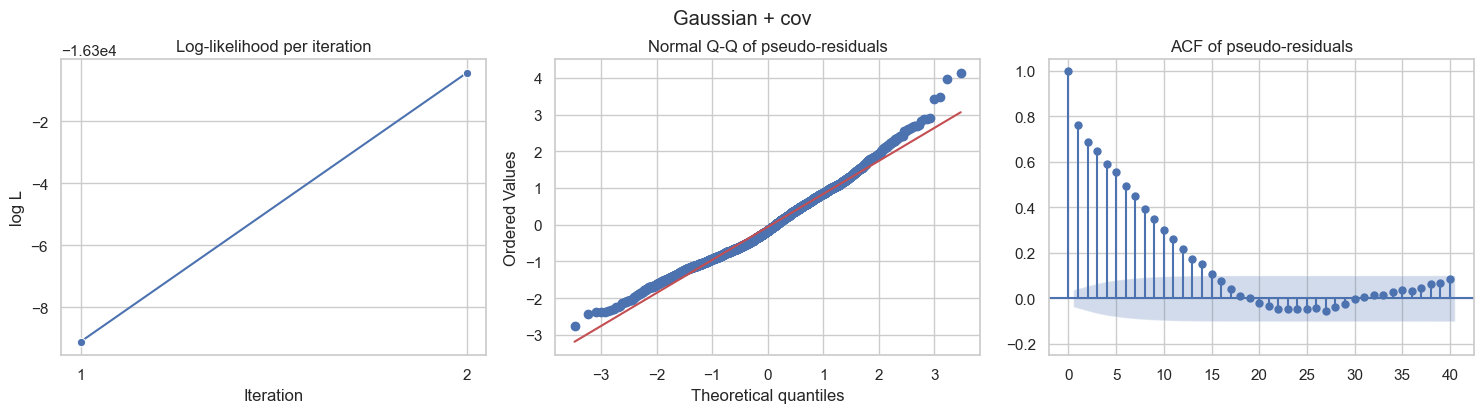

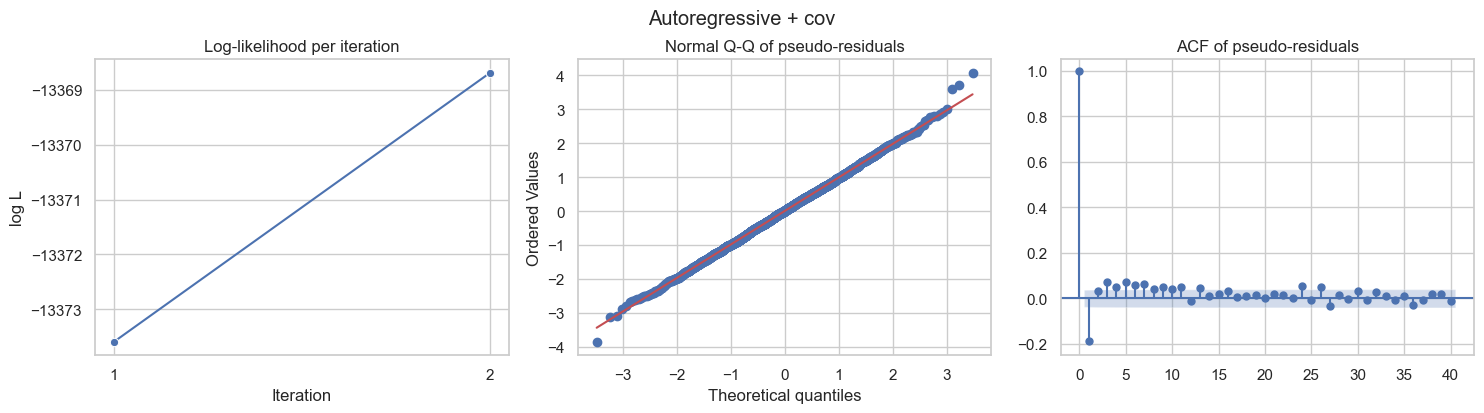

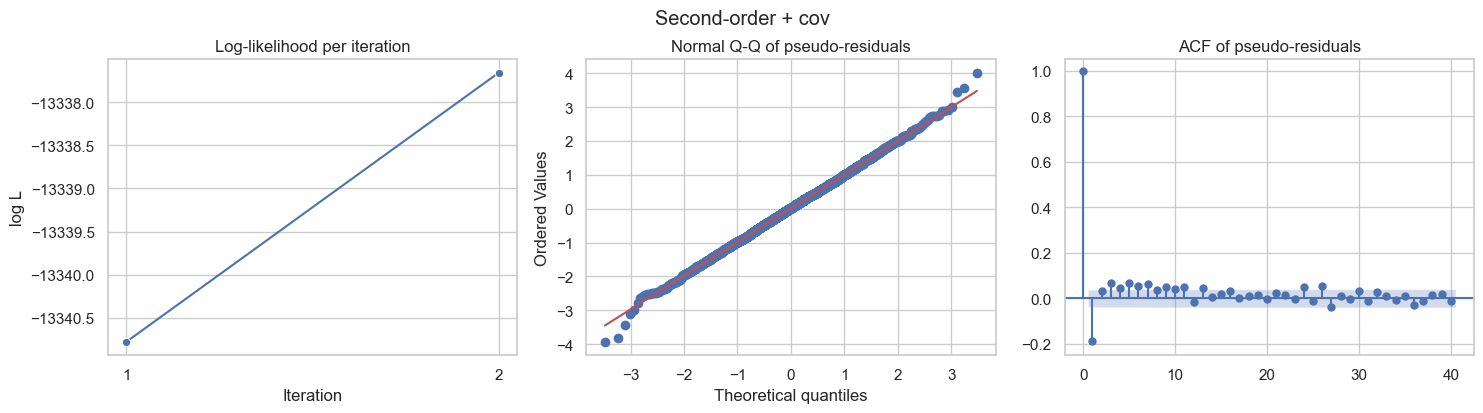

In [4]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

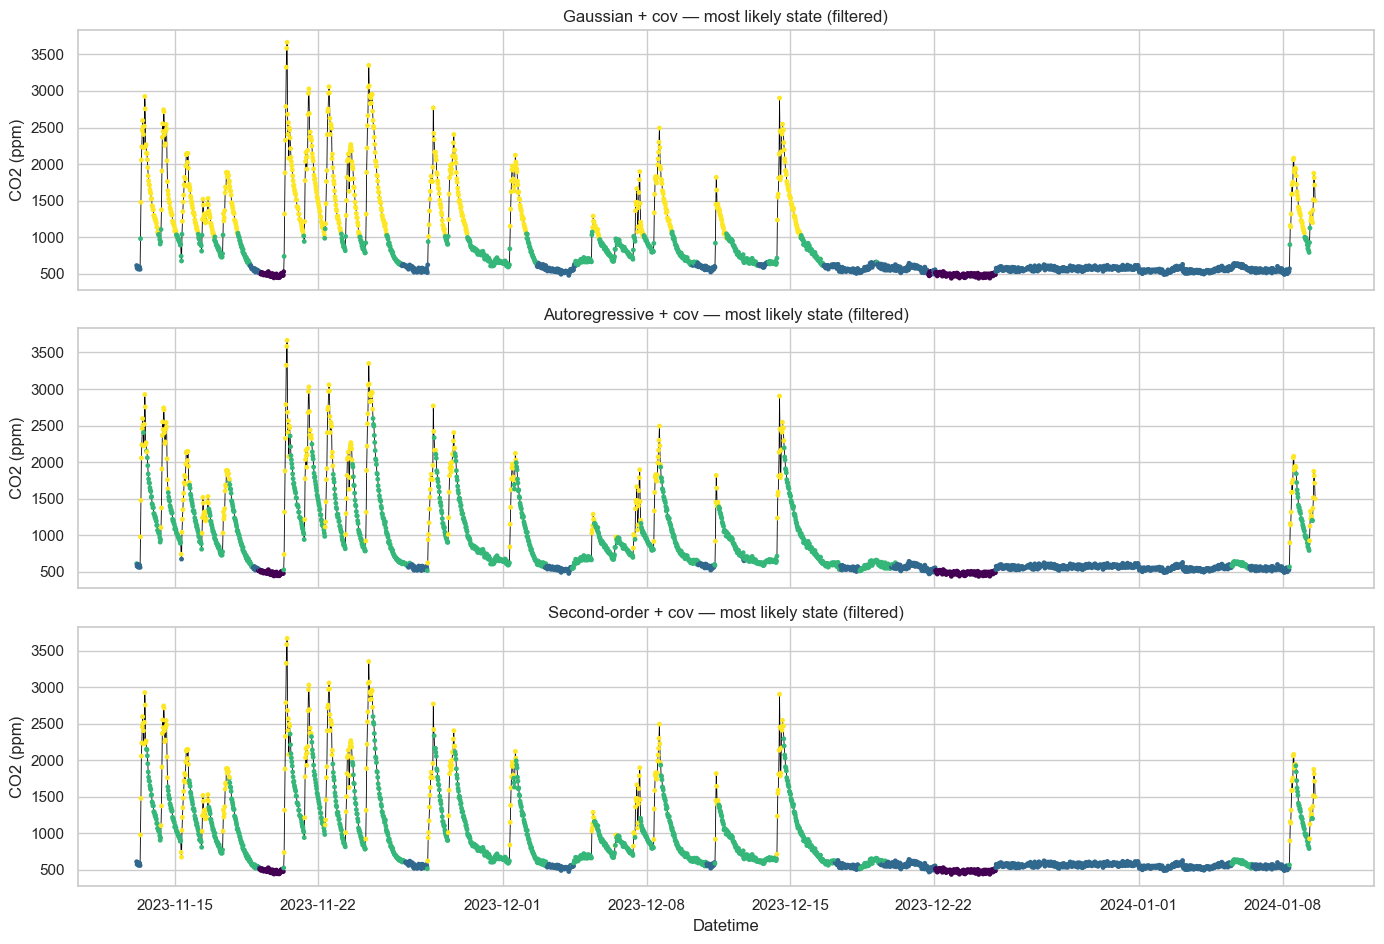

In [5]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order model
    # shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis", s=6, zorder=2)
    ax.set(title=f"{name} — most likely state (filtered)", ylabel="CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout(); plt.show()

## Rolling forecasts on the validation block

A fixed `HORIZON_HOURS`-ahead forecast anchored at *every* validation observation, against a
persistence baseline. The filtered state distribution at the anchor is propagated forward
through the covariate-driven transition matrices, and the emission mean is taken under the
resulting state distribution; for the autoregressive models each prediction is fed back in as
the next step's lag. Anchors stop `K` steps before the end of the block so every target lies
inside validation and nothing is scored against the training block.

In [6]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))

print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

start, end = TRAIN_IDX, len(ys)
forecasts = {"Persistence baseline": rolling_persistence(ys, start, end, K)}
for name, m in models.items():
    forecasts[name] = rolling_forecast(m, ys, X_std, start, end, K)

pred_table = pd.DataFrame([
    {"Model": name, "RMSE": rmse(yt, yp), "MAPE%": mape(yt, yp), "R2": r2_score(yt, yp), "n": len(yt)}
    for name, (idx, yt, yp) in forecasts.items()
]).sort_values("RMSE").reset_index(drop=True)

write_latex_table(pred_table.round(3), TABLE_DIR / "validation_forecast.tex",
                  caption=f"Rolling {HORIZON_HOURS}-hour-ahead validation forecast accuracy, "
                          f"{room_name} ({BIN}).",
                  label="tab:week5-validation-forecast")
pred_table.round(3)

Horizon: 6 h = 12 steps


,Model,RMSE,MAPE%,R2,n
0,Autoregressive + cov,329.032,16.634,0.678,625
1,Second-order + cov,333.591,17.009,0.669,625
2,Gaussian + cov,414.473,23.211,0.488,625
3,Persistence baseline,524.299,23.290,0.181,625


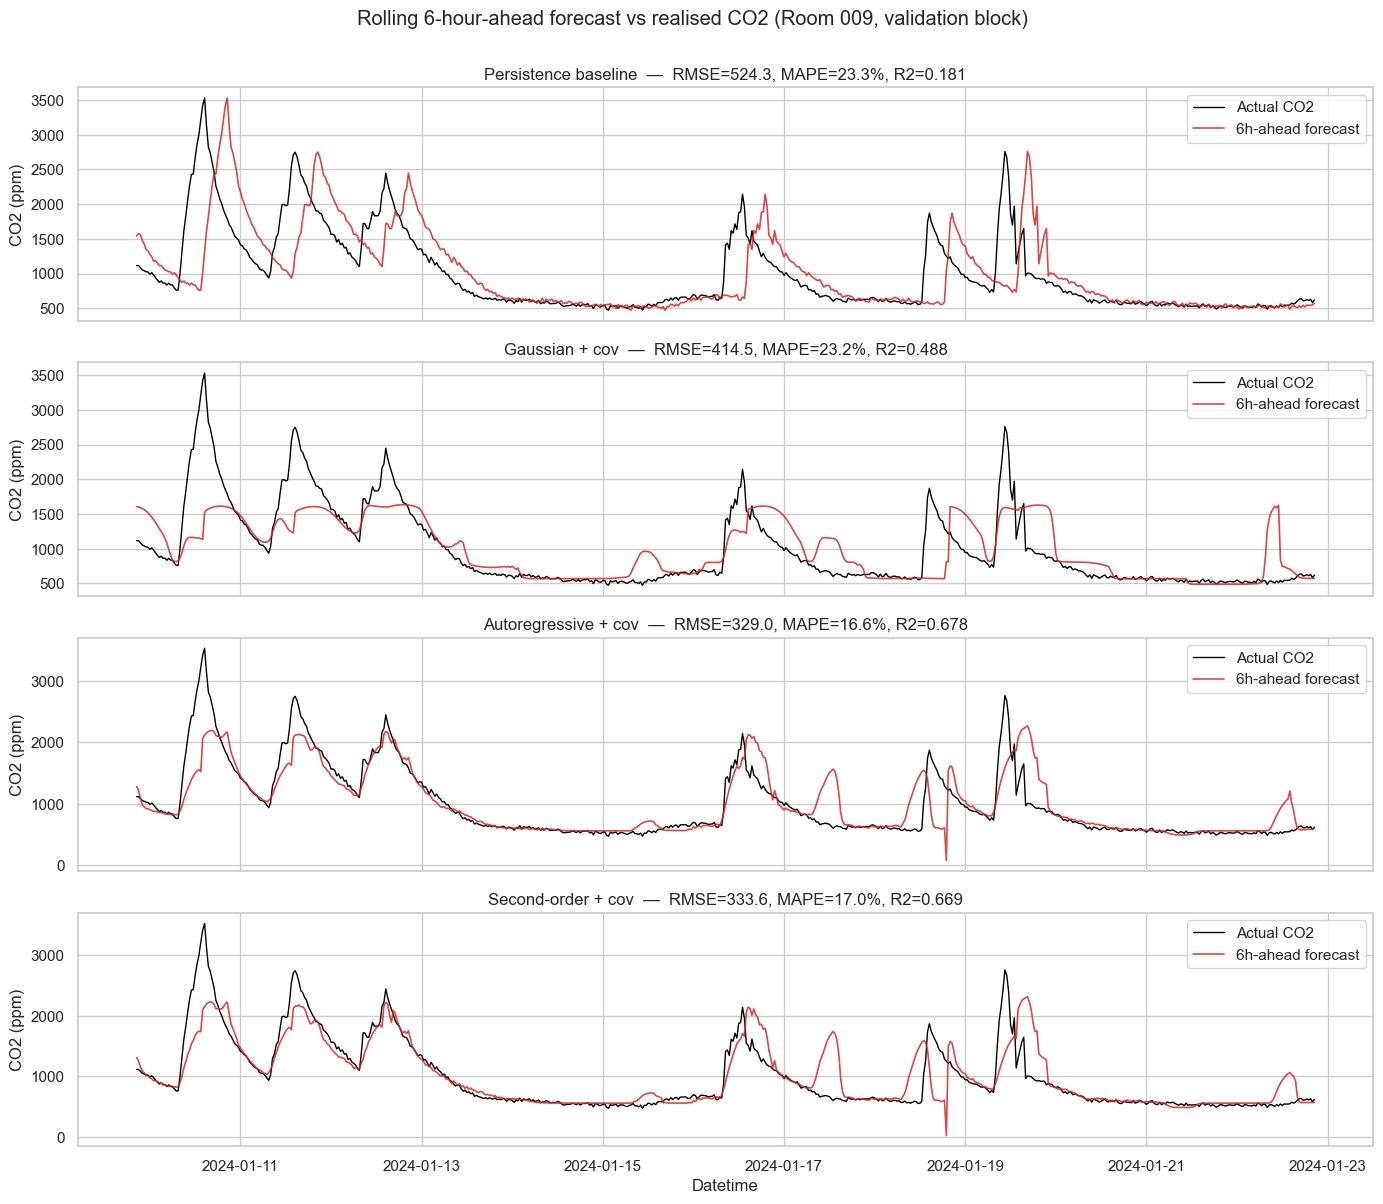

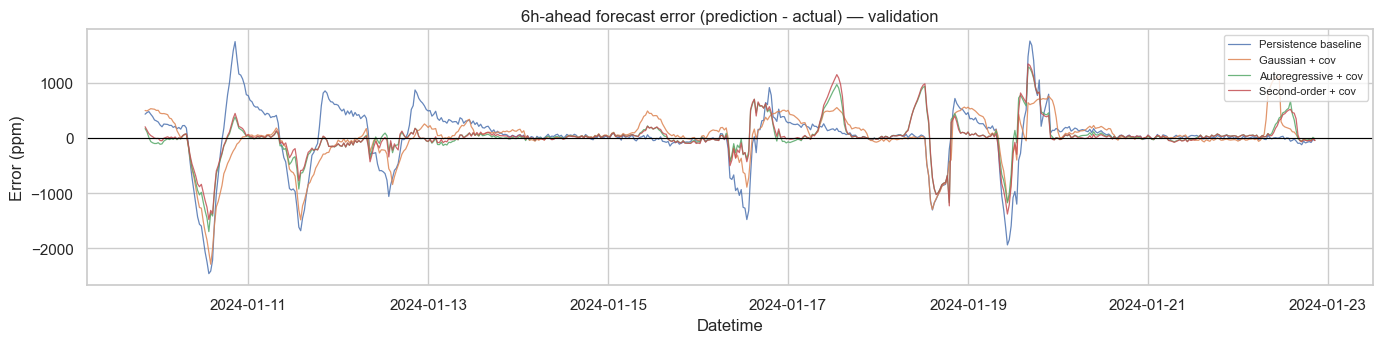

In [7]:
# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 3 * len(forecasts)), sharex=True)
for ax, (name, (idx, yt, yp)) in zip(np.atleast_1d(axes), forecasts.items()):
    ax.plot(dates[idx], yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(dates[idx], yp, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}", ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation block)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp) in forecasts.items():
    ax.plot(dates[idx], yp - yt, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — validation",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## Fitting the working-day runs as a batch

Off days cut the series into **runs of consecutive working days**. Treating the whole
training block as one sequence forces the chain to carry state across a weekend, which is
exactly the transition the covariates cannot explain. Each run is instead an independent
sequence sharing one parameter set, so the batch log-likelihood is the sum of the
per-run log-likelihoods.

The runs have different lengths (a normal week gives 5 working days, a week with a public
holiday fewer), so `batched=True` is handed a *list* of sequences. `ForwardAlgorithm.run`
pads them to a common length and masks the padding out: a padded step gets emission
density 1, hence a likelihood factor of exactly 1 and a log-likelihood contribution of
exactly 0.

In [8]:
# --- split the series into runs of consecutive working days -------------------------
import numpy as np

def working_day_runs(off_day) -> list[np.ndarray]:
    """Index groups of consecutive working-day bins.

    Returns the *indices* rather than the data, so `ys`, the covariates and the
    timestamps are all sliced with the same groups. Indexing the first axis directly is
    what makes this work for a 1-D `ys` and a 2-D covariate matrix alike: promoting a
    1-D `ys` with `jnp.atleast_2d` first would turn it into a single (1, N) row, and JAX
    *clamps* the out-of-range row indices instead of raising, so every run would come
    back as copies of the whole series.
    """
    off = np.asarray(off_day, dtype=bool)
    idx = np.flatnonzero(~off)
    breaks = np.flatnonzero(np.diff(idx) > 1) + 1
    return [g for g in np.split(idx, breaks) if len(g)]

if not USE_OFF_DAY:
    raise ValueError("this section splits on the off_day flag — set USE_OFF_DAY = True")

# Rebuilt here so the section stands on its own rather than on whatever X_raw happens
# to hold from an earlier run.
X_raw_b, cov_cols_b = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=WEATHER,
)

OFF_COL     = cov_cols_b.index("off_day")
off_day_all = X_raw_b[:, OFF_COL] == 1

# The flag is constant within a working-day run, so inside a run it cannot inform the
# transition at all: it is dropped from the design matrix and kept only as the splitter.
# (Note this drops a *column*, not a row — dropping a row would shift every covariate
# one bin out of alignment with ys.)
keep           = [j for j in range(X_raw_b.shape[1]) if j != OFF_COL]
Xb_std, _, _   = standardise(X_raw_b[:, keep], TRAIN_IDX)
Xb_std         = jnp.asarray(Xb_std)
cov_cols_batch = [cov_cols_b[j] for j in keep]
num_cov_batch  = Xb_std.shape[1]

# Runs within each block; validation indices are shifted back to absolute positions so
# they index `ys` and `dates` directly.
train_runs = working_day_runs(off_day_all[:TRAIN_IDX])
val_runs   = [g + TRAIN_IDX for g in working_day_runs(off_day_all[TRAIN_IDX:])]

ys_train_batch = [ys[g] for g in train_runs]
xs_train_batch = [Xb_std[g] for g in train_runs]
ys_val_batch   = [ys[g] for g in val_runs]
xs_val_batch   = [Xb_std[g] for g in val_runs]

BINS_PER_DAY = int(round(86400 / BIN_SECONDS))
for label, runs, batch in [("train", train_runs, ys_train_batch),
                           ("validation", val_runs, ys_val_batch)]:
    lengths = [len(g) for g in runs]
    padded  = len(lengths) * max(lengths)
    print(f"{label:<11} {len(runs):>3} runs, "
          f"{sum(lengths)} of {len(ys_train) if label == 'train' else len(ys_val)} bins kept, "
          f"lengths (working days): {[round(L / BINS_PER_DAY, 1) for L in lengths]}")
    print(f"{'':<11} padded to {max(lengths)} -> {padded - sum(lengths)} padded bins "
          f"({100 * (1 - sum(lengths) / padded):.1f}% of the batch, masked out of the likelihood)")

print(f"\ncovariates in the transition ({num_cov_batch}): {', '.join(cov_cols_batch)}")
assert all(len(y) == len(x) for y, x in zip(ys_train_batch, xs_train_batch))
assert all(y.ndim == 1 and x.ndim == 2 for y, x in zip(ys_train_batch, xs_train_batch))

train         9 runs, 1846 of 2758 bins kept, lengths (working days): [4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 3.0, 4.0, 1.6]
            padded to 240 -> 314 padded bins (14.5% of the batch, masked out of the likelihood)
validation    3 runs, 445 of 637 bins kept, lengths (working days): [3.4, 5.0, 0.9]
            padded to 240 -> 275 padded bins (38.2% of the batch, masked out of the likelihood)

covariates in the transition (6): sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, mean_temp, mean_relative_hum


## Fitting the two models on the batch

The same warm-start chain as the single-sequence fits: the Gaussian fit seeds the
autoregressive one. Both are fitted on the *batch* of working-day runs, so the
log-likelihoods here are comparable to each other but not to the single-sequence fits
above — they are computed over fewer observations (off days dropped) and without the
weekend transitions.

In [9]:
beta_init_batch = jnp.zeros((num_cov_batch, STATES, STATES - 1))
FIT_KW_BATCH    = dict(ts=None, tol=FIT_TOL, frozen=FROZEN, batched=True)

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates (working-day runs) ===")
gauss_cov_batch = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init_batch),
    inital_distribution=init_dist,
)
gauss_cov_batch.fit(ys=ys_train_batch, xs=xs_train_batch, **FIT_KW_BATCH)
print(f"  log-likelihood: {gauss_cov_batch.log_likelihood():.4f}   "
      f"converged: {gauss_cov_batch.hmm_results.convergence}")

# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates (working-day runs) ===")
ar_cov_batch = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov_batch.emission, ys_train_batch[0]),
        jnp.exp(gauss_cov_batch.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov_batch.transition.transition_logits,
                                 gauss_cov_batch.transition.beta),
    inital_distribution=init_dist,
)
ar_cov_batch.fit(ys=ys_train_batch, xs=xs_train_batch, **FIT_KW_BATCH)
print(f"  log-likelihood: {ar_cov_batch.log_likelihood():.4f}   "
      f"converged: {ar_cov_batch.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov_batch.emission.phi())}")

models_batch = {"Gaussian + cov (runs)": gauss_cov_batch,
                "Autoregressive + cov (runs)": ar_cov_batch}

# The padding must not have entered the likelihood: the batch log-likelihood has to equal
# the sum of the per-run log-likelihoods, each computed on its own unpadded sequence.
for name, m in models_batch.items():
    batched_ll = m.log_likelihood(ys_train_batch, xs=xs_train_batch, batched=True)
    summed_ll  = sum(m.log_likelihood(y, xs=x) for y, x in zip(ys_train_batch, xs_train_batch))
    print(f"{name}: batched {batched_ll:.6f} vs summed {summed_ll:.6f} "
          f"(diff {abs(batched_ll - summed_ll):.2e})")

=== Gaussian HMM + covariates (working-day runs) ===
  log-likelihood: -11582.5297   converged: True
=== Autoregressive HMM + covariates (working-day runs) ===
  log-likelihood: -9256.7000   converged: True
  phi (per state): [[0.32725938 0.7115437  0.94803326 0.86614647]]
Gaussian + cov (runs): batched -11582.529667 vs summed -11582.529667 (diff 0.00e+00)
Autoregressive + cov (runs): batched -9256.699970 vs summed -9256.699970 (diff 0.00e+00)


## Rolling forecasts on the validation runs

The validation block is split into working-day runs the same way, and a fixed
`HORIZON_HOURS`-ahead forecast is anchored at every bin of every run. Each run is forecast
on its own — the filtered state at an anchor is built from that run's own history, so no
forecast reaches across an off-day gap, and no anchor in one run targets a bin in the next.

The scores are **pooled**: the targets and predictions of every run are concatenated and
scored once. That is not the same as averaging the per-run R2 values — pooling uses a
single variance over all validation targets, so a short run cannot weigh as much as a long
one, and a run whose own variance is small cannot produce a wildly negative R2 that drags
the mean down. The per-run spread is printed underneath so the pooled number is not hiding
it.

These numbers are **not comparable to the whole-block scores further up**: those include
off days, where CO2 sits flat at baseline and is trivially predictable, which inflates R2.
Everything here is scored on working days only.

In [10]:
# rolling_forecast needs start >= k - 1: below that, ys[anchors - j] indexes negatively
# and JAX *wraps*, silently taking a run's first anchors' lags from its last observations.
# One shared start for every model, so all of them are scored on identical anchors.
AR_START = AR_LAGS - 1
_pooled_models = {**models_batch, **models}
assert all(m.emission.phi().shape[0] == AR_LAGS
           for m in _pooled_models.values() if hasattr(m.emission, "phi")), \
    f"a fitted AR model disagrees with AR_LAGS={AR_LAGS} - re-run the fit cells"

print(f"Horizon: {HORIZON_HOURS} h = {K} steps; "
      f"{sum(1 for y in ys_val_batch if len(y) > K)} of {len(ys_val_batch)} validation runs "
      f"are longer than the horizon")

def pooled_run_forecast(model, runs, ys_batch, xs_batch):
    """Forecast every run separately, then pool the targets and predictions.

    `rolling_forecast` returns target indices *local* to the run it was given, so each is
    mapped back through the run's own index group to an absolute position in `ys` /
    `dates`. Without that the pooled series cannot be put on a time axis.
    """
    idx_all, yt_all, yp_all, per_run = [], [], [], []
    for g, y_run, x_run in zip(runs, ys_batch, xs_batch):
        if len(y_run) <= K + AR_START:  # no anchor leaves a target inside the run
            continue
        local_idx, yt, yp = rolling_forecast(model, y_run, x_run, AR_START, len(y_run), K)
        idx_all.append(np.asarray(g)[local_idx])
        yt_all.append(yt); yp_all.append(yp)
        per_run.append(r2_score(yt, yp))
    return (np.concatenate(idx_all), np.concatenate(yt_all),
            np.concatenate(yp_all), per_run)

def pooled_run_persistence(runs, ys_batch):
    idx_all, yt_all, yp_all, per_run = [], [], [], []
    for g, y_run in zip(runs, ys_batch):
        if len(y_run) <= K + AR_START:
            continue
        local_idx, yt, yp = rolling_persistence(y_run, AR_START, len(y_run), K)
        idx_all.append(np.asarray(g)[local_idx])
        yt_all.append(yt); yp_all.append(yp)
        per_run.append(r2_score(yt, yp))
    return (np.concatenate(idx_all), np.concatenate(yt_all),
            np.concatenate(yp_all), per_run)

pooled = {"Persistence baseline": pooled_run_persistence(val_runs, ys_val_batch)}
#Extend the batch notebook with the other models, so the pooled table has all of them

for name, m in models_batch.items():
    pooled[name] = pooled_run_forecast(m, val_runs, ys_val_batch, xs_val_batch)

xs_val_batch_full = [X_std[g] for g in val_runs]  # the batch notebook dropped the off_day column
for name, m in models.items():
    pooled[name] = pooled_run_forecast(m, val_runs, ys_val_batch, xs_val_batch_full)


val_table = pd.DataFrame([
    {"Model": name,
     "RMSE": rmse(yt, yp),
     "MAPE%": mape(yt, yp),
     "R2 (pooled)": r2_score(yt, yp),
     "R2 (per-run mean)": float(np.mean(per_run)),
     "R2 (per-run min)": float(np.min(per_run)),
     "Runs": len(per_run),
     "n": len(yt)}
    for name, (_idx, yt, yp, per_run) in pooled.items()
]).sort_values("RMSE").reset_index(drop=True)


for name, (_idx, yt, yp, per_run) in pooled.items():
    print(f"{name}: pooled R2 = {r2_score(yt, yp):.4f}  "
          f"per-run R2 = [{min(per_run):.3f}, {max(per_run):.3f}] over {len(per_run)} runs")

val_table.round(3)

Horizon: 6 h = 12 steps; 3 of 3 validation runs are longer than the horizon
Persistence baseline: pooled R2 = -0.0422  per-run R2 = [-0.895, -0.498] over 3 runs
Gaussian + cov (runs): pooled R2 = 0.3774  per-run R2 = [-53.445, 0.032] over 3 runs
Autoregressive + cov (runs): pooled R2 = 0.5462  per-run R2 = [-62.951, 0.579] over 3 runs
Gaussian + cov: pooled R2 = 0.3560  per-run R2 = [-23.208, -0.001] over 3 runs
Autoregressive + cov: pooled R2 = 0.4710  per-run R2 = [-180.695, 0.557] over 3 runs
Second-order + cov: pooled R2 = 0.4889  per-run R2 = [-151.948, 0.641] over 3 runs


,Model,RMSE,MAPE%,R2 (pooled),R2 (per-run mean),R2 (per-run min),Runs,n
0,Autoregressive + cov (runs),422.606,25.908,0.546,-20.811,-62.951,3,409
1,Second-order + cov,448.504,29.370,0.489,-50.514,-151.948,3,409
2,Autoregressive + cov,456.285,30.078,0.471,-60.100,-180.695,3,409
3,Gaussian + cov (runs),494.994,29.920,0.377,-17.813,-53.445,3,409
4,Gaussian + cov,503.450,29.807,0.356,-7.764,-23.208,3,409
5,Persistence baseline,640.447,29.651,-0.042,-0.654,-0.895,3,409


## Forecast vs realised over the validation runs

The same view as the whole-block forecast plots further up, restricted to the validation
working-day runs. The x axis is wall time, so the off-day gaps between runs are visible as
breaks: the lines are split there rather than drawn straight across, since no forecast
spans a gap.

This is the genuinely out-of-sample view. It is the one to judge the models on — an
in-sample plot of the *filtered* mean would look far tighter without meaning anything,
because the filtered state at bin t is conditioned on y_t itself.

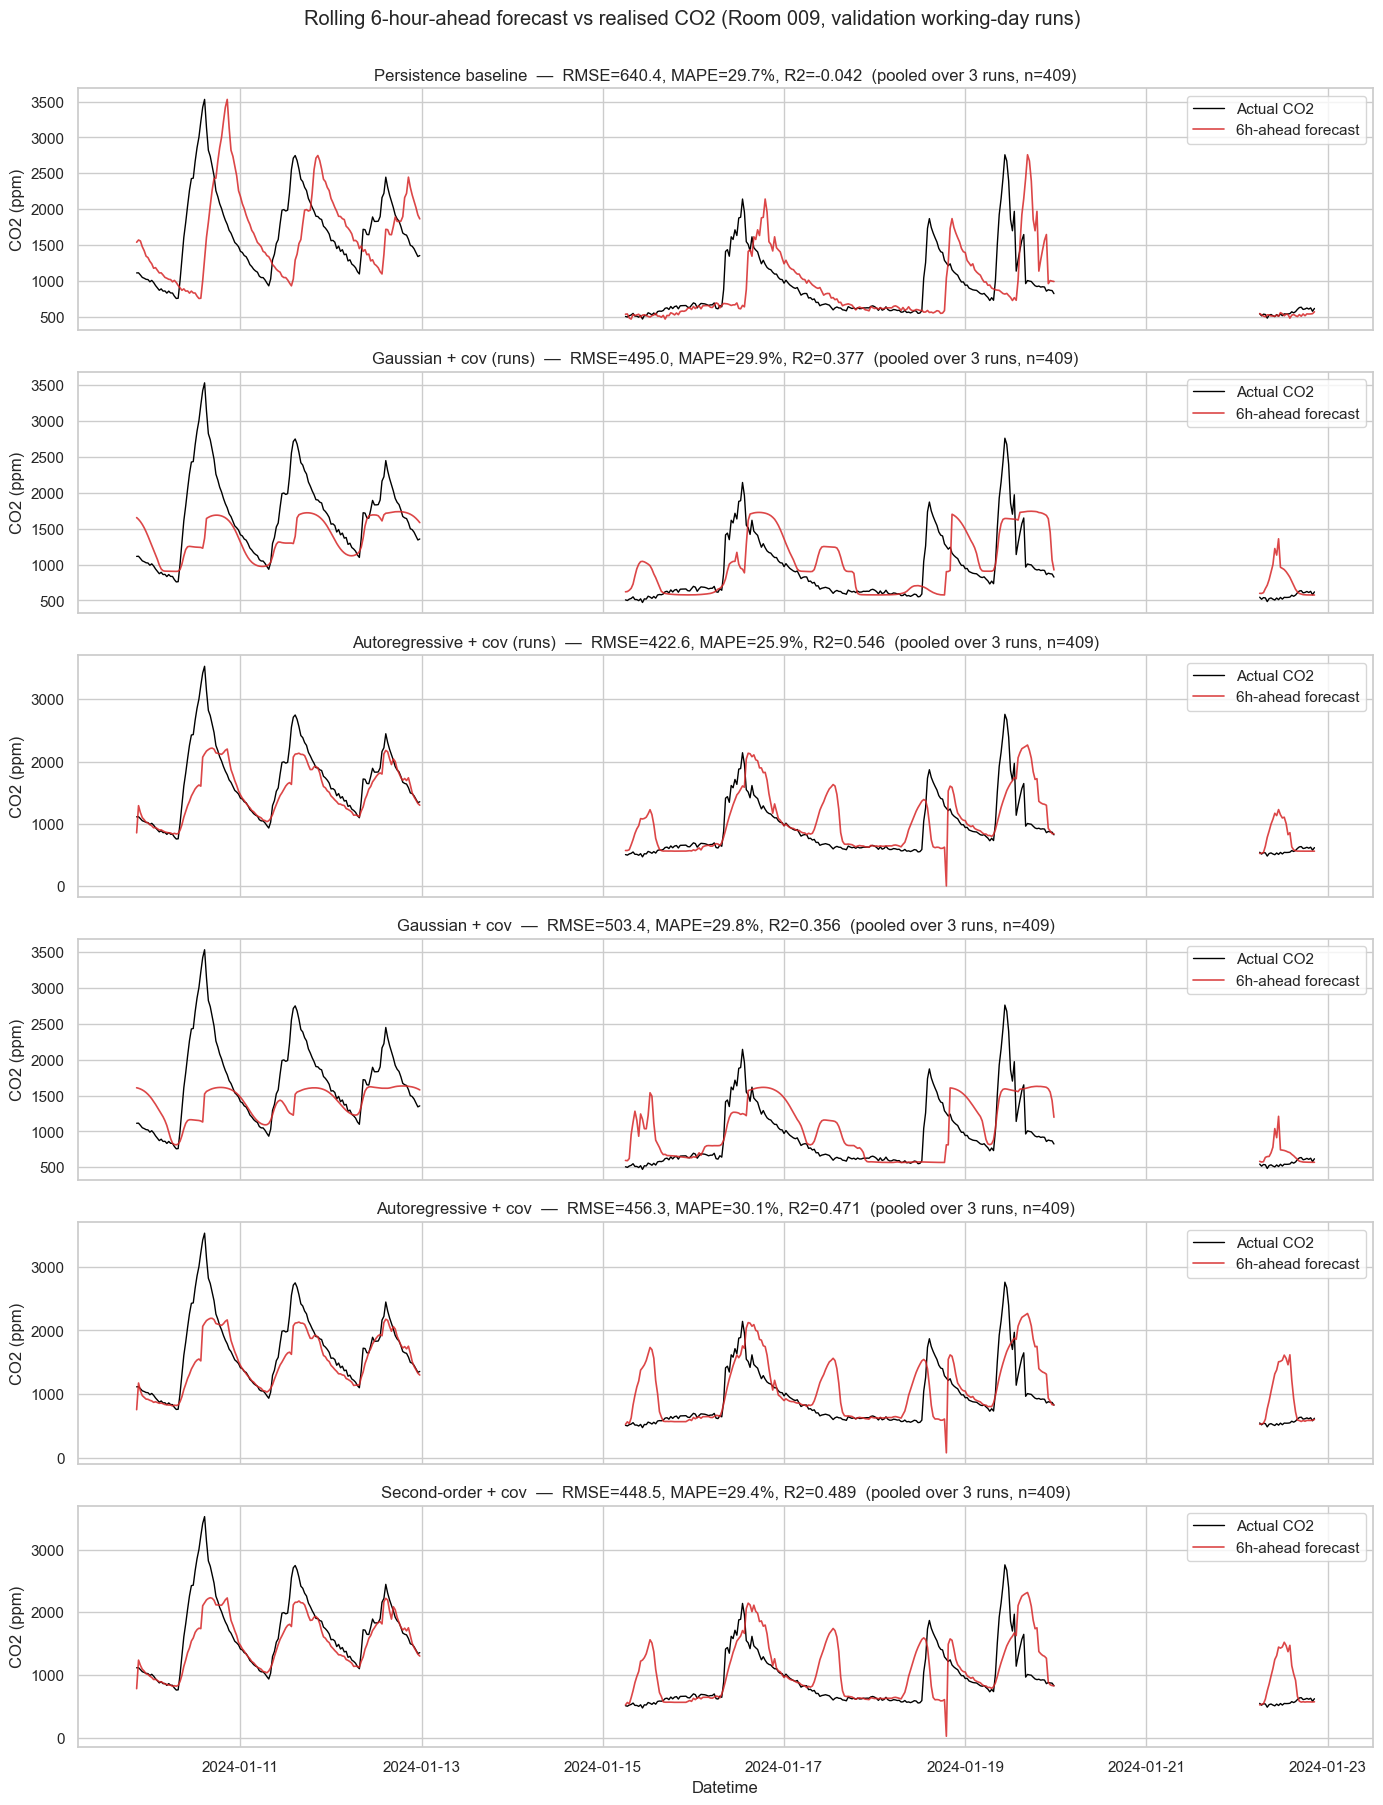

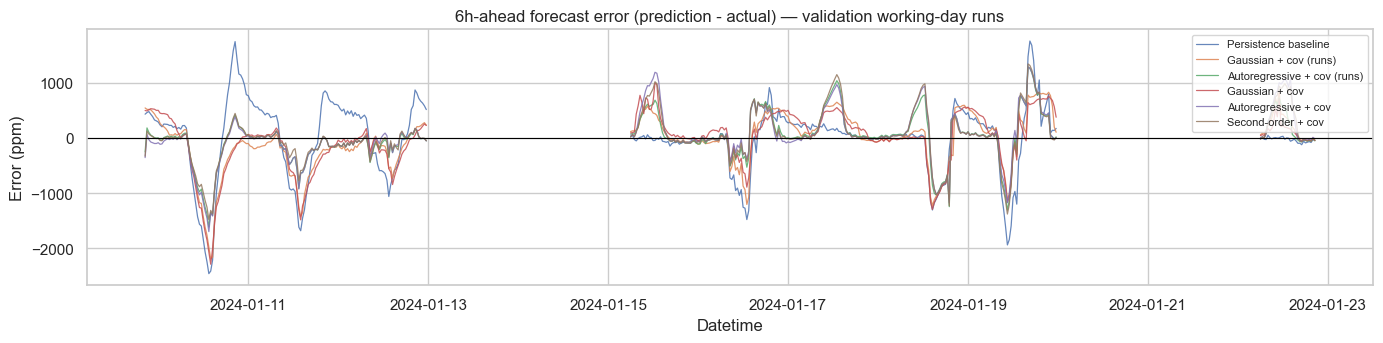

In [11]:
def break_at_gaps(idx, values):
    """Split a pooled series at run boundaries so no line bridges an off-day gap.

    A NaN is inserted wherever the absolute index jumps by more than one bin; matplotlib
    lifts the pen there.
    """
    idx    = np.asarray(idx)
    values = np.asarray(values, dtype=float)
    jumps  = np.flatnonzero(np.diff(idx) > 1) + 1
    d, v   = list(dates[idx]), list(values)
    for k in reversed(jumps):                       # back to front, so earlier positions hold
        d.insert(k, dates[idx[k - 1]] + pd.Timedelta(BIN))
        v.insert(k, np.nan)
    return pd.DatetimeIndex(d), np.asarray(v)

# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(pooled), 1, figsize=(14, 3 * len(pooled)), sharex=True)
for ax, (name, (idx, yt, yp, per_run)) in zip(np.atleast_1d(axes), pooled.items()):
    d, yt_g = break_at_gaps(idx, yt)
    _, yp_g = break_at_gaps(idx, yp)
    ax.plot(d, yt_g, color="black", lw=1.0, label="Actual CO2")
    ax.plot(d, yp_g, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}  (pooled over {len(per_run)} runs, n={len(yt)})",
           ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation working-day runs)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp, _per_run) in pooled.items():
    d, err = break_at_gaps(idx, yp - yt)
    ax.plot(d, err, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — "
             f"validation working-day runs",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()